# VisualSearch: извлечение эмбеддингов и построение FAISS-индекса

In [1]:
import gc
import json
import sys
import time
from pathlib import Path

import faiss
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
import yaml
from PIL import Image
from tqdm.notebook import tqdm

try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    ALBUMENTATIONS_AVAILABLE = True
except ImportError:
    ALBUMENTATIONS_AVAILABLE = False
    print("⚠️ albumentations not installed: pip install albumentations")

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")


Project root: d:\VSCode\CK\aie-student-template\project


In [2]:
def load_config(config_path: str = "configs/project.yaml") -> dict:
    """Загружает YAML-конфиг, преобразует относительные пути в абсолютные."""
    config_file = PROJECT_ROOT / config_path
    if not config_file.exists():
        raise FileNotFoundError(f"Config not found: {config_file}")
    with open(config_file, encoding="utf-8") as f:
        config = yaml.safe_load(f)
    for key, value in config.get("paths", {}).items():
        if isinstance(value, str) and not Path(value).is_absolute():
            config["paths"][key] = str(PROJECT_ROOT / value)
    return config


config = load_config()
print(
    f"Config loaded:\n"
    f"  images : {config['paths']['images_dir']}\n"
    f"  artifacts: {config['paths']['artifacts_dir']}\n"
    f"  model  : {config['model']['name']} on {config['model']['device']}\n"
    f"  index  : {config['index']['type']} nlist={config['index']['nlist']} nprobe={config['index']['nprobe']}\n"
    f"  batch  : {config['inference']['batch_size']}  top_k={config['inference']['top_k']}"
)


Config loaded:
  images : d:\VSCode\CK\aie-student-template\project\data\dataset\images
  artifacts: d:\VSCode\CK\aie-student-template\project\artifacts
  model  : resnet50 on cuda
  index  : Flat nlist=500 nprobe=5
  batch  : 64  top_k=5


In [3]:
def load_image_paths(directory: str, extensions: list = None) -> list:
    """Рекурсивно собирает и сортирует пути к изображениям."""
    extensions = [e.lower() for e in (extensions or [".jpg", ".jpeg"])]
    directory = Path(directory)
    paths = []
    for ext in extensions:
        paths.extend(directory.rglob(f"*{ext}"))
    return sorted(str(p) for p in paths)


image_paths = load_image_paths(config["paths"]["images_dir"])
metadata = pd.DataFrame({
    "index"   : range(len(image_paths)),
    "filename": [Path(p).name for p in image_paths],
    "filepath": image_paths,
})
print(f"Found {len(metadata)} images")
metadata.head()


Found 44096 images


,index,filename,filepath
0,0,MEN-Denim-id_00000080-01_7_additional.jpg,d:\VSCode\CK\aie-student-template\project\data...
1,1,MEN-Denim-id_00000089-01_7_additional.jpg,d:\VSCode\CK\aie-student-template\project\data...
2,2,MEN-Denim-id_00000089-02_7_additional.jpg,d:\VSCode\CK\aie-student-template\project\data...
3,3,MEN-Denim-id_00000089-03_7_additional.jpg,d:\VSCode\CK\aie-student-template\project\data...
4,4,MEN-Denim-id_00000089-04_7_additional.jpg,d:\VSCode\CK\aie-student-template\project\data...


In [4]:
_IMAGENET_MEAN = [0.485, 0.456, 0.406]
_IMAGENET_STD  = [0.229, 0.224, 0.225]


def create_transforms(image_size: int = 224) -> tuple:
    """Возвращает (transform_train, transform_inference)."""
    transform_inference = T.Compose([
        T.Resize((image_size, image_size)),
        T.ToTensor(),
        T.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),
    ])

    if ALBUMENTATIONS_AVAILABLE:
        aug = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.RandomRotate90(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.3),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
            A.RandomBrightnessContrast(p=0.3),
            A.GaussianBlur(blur_limit=(3, 7), p=0.2),
            A.Normalize(mean=_IMAGENET_MEAN, std=_IMAGENET_STD),
            ToTensorV2(),
        ])
        def transform_train(img_pil):
            return aug(image=np.array(img_pil))["image"]
    else:
        transform_train = transform_inference

    return transform_train, transform_inference


transform_train, transform_inference = create_transforms(image_size=224)
print(f"Transforms ready. Train: {'albumentations' if ALBUMENTATIONS_AVAILABLE else 'torchvision'}")


Transforms ready. Train: albumentations


c:\Users\Karl\AppData\Local\Programs\Python\Python313\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [5]:
class EmbeddingModel(nn.Module):
    """
    Предобученная backbone без классификатора → L2-нормализованные эмбеддинги.
    Поддерживаемые модели: resnet18, resnet50, efficientnet_b0, clip_vit_b32.
    """

    _CONFIGS = {
        "resnet50"       : (models.resnet50,       models.ResNet50_Weights.IMAGENET1K_V1,       -1, 2048),
        "resnet18"       : (models.resnet18,        models.ResNet18_Weights.IMAGENET1K_V1,       -1,  512),
        "efficientnet_b0": (models.efficientnet_b0, models.EfficientNet_B0_Weights.IMAGENET1K_V1, -2, 1280),
    }

    def __init__(self, model_name: str = "resnet50", pretrained: bool = True):
        super().__init__()
        self.model_name = model_name
        self.is_clip    = False

        if model_name == "clip_vit_b32":
            try:
                import clip
                self.clip_model, self.preprocess = clip.load("ViT-B/32", device="cpu", jit=False)
                self.feature_extractor = self.clip_model.visual
                self.embedding_dim = 512
                self.is_clip = True
            except ImportError:
                raise ImportError("CLIP not installed: pip install git+https://github.com/openai/CLIP.git")
        elif model_name in self._CONFIGS:
            factory, weights_cls, slice_idx, dim = self._CONFIGS[model_name]
            backbone = factory(weights=weights_cls if pretrained else None)
            self.feature_extractor = nn.Sequential(*list(backbone.children())[:slice_idx])
            self.embedding_dim = dim
        else:
            raise ValueError(f"Unknown model: {model_name!r}. Choose from: {list(self._CONFIGS) + ['clip_vit_b32']}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.is_clip:
            return self.feature_extractor(x)
        features   = self.feature_extractor(x)           # [B, D, 1, 1]
        embeddings = features.view(features.size(0), -1) # [B, D]
        return nn.functional.normalize(embeddings, p=2, dim=1)


device = torch.device(config["model"]["device"] if torch.cuda.is_available() else "cpu")
model  = EmbeddingModel(model_name=config["model"]["name"]).to(device).eval()
print(f"Model: {config['model']['name']}  dim={model.embedding_dim}  device={device}")


Model: resnet50  dim=2048  device=cuda


c:\Users\Karl\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\cuda\__init__.py:287: UserWarning: 
NVIDIA GeForce RTX 5060 Ti with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5060 Ti GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [6]:
@torch.no_grad()
def extract_embeddings(
    image_paths : list,
    model       : nn.Module,
    transform,
    batch_size  : int = 64,
    device      : torch.device = torch.device("cpu"),
) -> np.ndarray:
    """Извлекает эмбеддинги батчами. Возвращает np.ndarray [N, D] float32."""
    embeddings_list, failed = [], []

    for i in tqdm(range(0, len(image_paths), batch_size), desc="Extracting"):
        batch_paths   = image_paths[i : i + batch_size]
        batch_tensors = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                batch_tensors.append(model.preprocess(img) if model.is_clip else transform(img))
            except Exception as e:
                failed.append((path, str(e)))
        if not batch_tensors:
            continue
        batch = torch.stack(batch_tensors).to(device)
        embeddings_list.append(model(batch).cpu().numpy())

    embeddings = np.vstack(embeddings_list)
    print(f"Embeddings: {embeddings.shape}  {embeddings.nbytes / 1024**2:.1f} MB")
    if failed:
        print(f"⚠️ Failed {len(failed)} images: {[Path(p).name for p, _ in failed[:5]]}")
    return embeddings


In [7]:
def build_faiss_index(
    embeddings : np.ndarray,
    index_type : str = "IVF",
    nlist      : int = 500,
    nprobe     : int = 5,
    metric     : str = "L2",
) -> faiss.Index:
    """
    Строит FAISS-индекс.
    index_type: Flat (точный, <10K), IVF (кластерный), HNSW (графовый).
    metric: L2 (для CNN), IP/cosine (для CLIP и нормализованных векторов).
    """
    if metric not in ("L2", "IP", "cosine"):
        raise ValueError(f"Unknown metric: {metric!r}")

    n, dim = embeddings.shape
    faiss_metric = faiss.METRIC_L2 if metric == "L2" else faiss.METRIC_INNER_PRODUCT

    if index_type == "Flat":
        index = faiss.IndexFlat(dim, faiss_metric)
    elif index_type == "IVF":
        quantizer = faiss.IndexFlatL2(dim)
        index = faiss.IndexIVFFlat(quantizer, dim, nlist, faiss_metric)
        index.train(embeddings)
        index.nprobe = nprobe
    elif index_type == "HNSW":
        index = faiss.IndexHNSWFlat(dim, 32, faiss_metric)
        index.hnsw.efSearch = 64
    else:
        raise ValueError(f"Unknown index_type: {index_type!r}")

    index.add(embeddings)
    print(f"Index [{index_type}] ready: {index.ntotal} vectors, dim={dim}, metric={metric}")
    return index


In [8]:
def parse_item_id(filename: str) -> str:
    """Извлекает item_id из имени файла DeepFashion: 'MEN-Denim-id_00000089-02_7.jpg' → 'id_00000089'."""
    name = Path(filename).stem
    for part in name.split("-"):
        if part.startswith("id_"):
            return part
    return name


def compute_retrieval_metrics(
    index                : faiss.Index,
    query_embeddings     : np.ndarray,
    query_filenames      : list,
    all_filenames        : list,
    query_index_positions: list,
    top_k                : int = 5,
) -> dict:
    """Вычисляет Recall@K, Precision@K, MRR и среднюю латентность."""
    K = min(top_k + 1, index.ntotal)  # +1 чтобы после выброса self осталось top_k

    t0 = time.perf_counter()
    _, indices = index.search(query_embeddings.astype(np.float32), K)
    latency_ms = (time.perf_counter() - t0) * 1000 / len(query_embeddings)

    recall_hits, precision_hits, rr_list = [], [], []
    for q_idx, idx_row in enumerate(indices):
        q_id     = parse_item_id(query_filenames[q_idx])
        self_pos = query_index_positions[q_idx]

        retrieved = []
        for pos in idx_row:
            if pos < 0 or pos >= len(all_filenames) or pos == self_pos:
                continue
            retrieved.append(all_filenames[pos])
            if len(retrieved) == top_k:
                break

        hits = [parse_item_id(f) == q_id for f in retrieved]
        recall_hits.append(int(any(hits)))
        precision_hits.append(sum(hits) / top_k if hits else 0.0)
        first_hit = next((i + 1 for i, h in enumerate(hits) if h), None)
        rr_list.append(1.0 / first_hit if first_hit else 0.0)

    return {
        f"Recall@{top_k}"   : float(np.mean(recall_hits)),
        f"Precision@{top_k}": float(np.mean(precision_hits)),
        "MRR"               : float(np.mean(rr_list)),
        "Latency(ms/q)"     : round(latency_ms, 2),
    }



RESNET18


Extracting:   0%|          | 0/689 [00:00<?, ?it/s]

Embeddings: (44096, 512)  86.1 MB
Index [Flat] ready: 44096 vectors, dim=512, metric=L2
Recall@5: 0.4420

EFFICIENTNET_B0


Extracting:   0%|          | 0/689 [00:00<?, ?it/s]

Embeddings: (44096, 62720)  10550.3 MB
Index [Flat] ready: 44096 vectors, dim=62720, metric=L2
Recall@5: 0.5420

RESNET50


Extracting:   0%|          | 0/689 [00:00<?, ?it/s]

Embeddings: (44096, 2048)  344.5 MB
Index [Flat] ready: 44096 vectors, dim=2048, metric=L2
Recall@5: 0.4940

          Model  Emb dim  Params (M)  Recall@5  Prec@5    MRR  Latency(ms/q)
       resnet18      512          11    0.4420  0.1440 0.3623         0.1000
efficientnet_b0     1280           5    0.5420  0.1780 0.4298         7.7100
       resnet50     2048          25    0.4940  0.1592 0.3739         0.2900


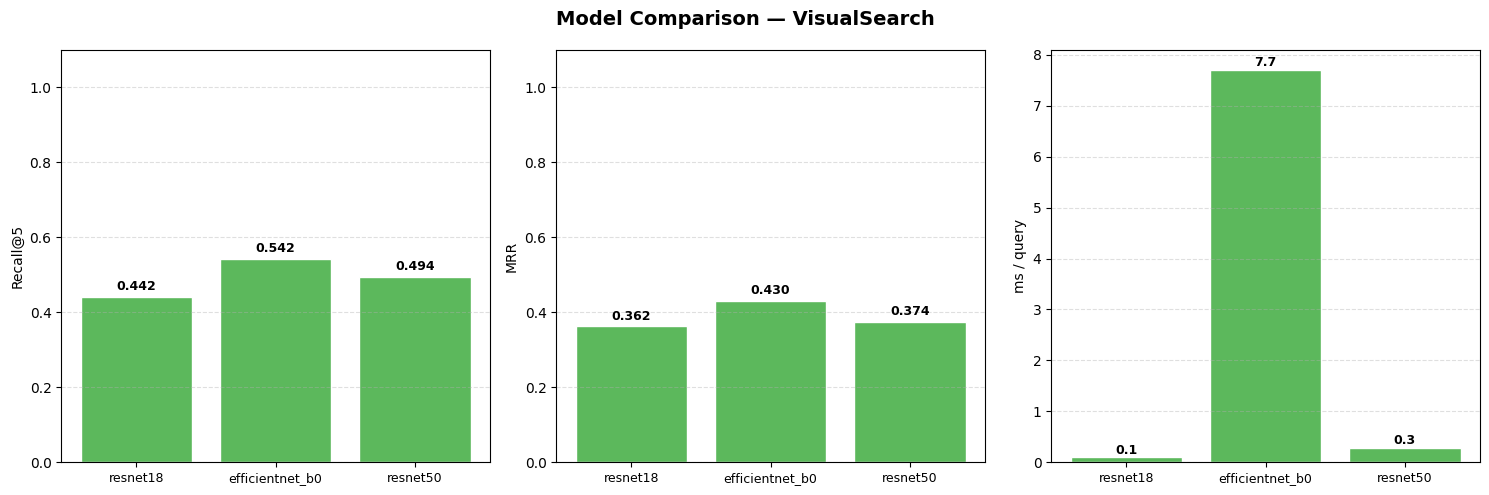

Saved: d:\VSCode\CK\aie-student-template\project\artifacts\model_comparison.png
Best Recall@5: efficientnet_b0


In [9]:
TOP_K        = config["inference"]["top_k"]
EVAL_QUERIES = 500
MODEL_NAMES  = ["resnet18", "efficientnet_b0", "resnet50"]
PARAMS_MAP   = {"resnet18": 11, "efficientnet_b0": 5, "resnet50": 25}

rng           = np.random.default_rng(42)
q_idx_arr     = rng.choice(len(metadata), size=min(EVAL_QUERIES, len(metadata)), replace=False)
eval_q_idx    = q_idx_arr.tolist()
eval_q_fnames = metadata.iloc[q_idx_arr]["filename"].tolist()
eval_all_fnames = metadata["filename"].tolist()

device_curr   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
COMPARISON_DATA = []
model = faiss_index = None  # будут заполнены для resnet50

for model_name in MODEL_NAMES:
    print(f"\n{'='*50}\n{model_name.upper()}\n{'='*50}")
    try:
        curr_model = EmbeddingModel(model_name=model_name).to(device_curr).eval()

        curr_embeddings = extract_embeddings(
            image_paths=image_paths,
            model=curr_model,
            transform=transform_inference,
            batch_size=config["inference"]["batch_size"],
            device=device_curr,
        )

        # Flat-индекс для честного сравнения (без погрешности IVF)
        curr_index = build_faiss_index(curr_embeddings, index_type="Flat", metric="L2")

        curr_metrics = compute_retrieval_metrics(
            index=curr_index,
            query_embeddings=curr_embeddings[eval_q_idx].astype(np.float32),
            query_filenames=eval_q_fnames,
            all_filenames=eval_all_fnames,
            query_index_positions=eval_q_idx,
            top_k=TOP_K,
        )

        if model_name == "resnet50":
            embeddings = curr_embeddings
            model = curr_model
            faiss_index = curr_index

        COMPARISON_DATA.append({
            "Model"          : model_name,
            "Emb dim"        : curr_model.embedding_dim,
            "Params (M)"     : PARAMS_MAP.get(model_name, 0),
            f"Recall@{TOP_K}": curr_metrics[f"Recall@{TOP_K}"],
            f"Prec@{TOP_K}"  : curr_metrics[f"Precision@{TOP_K}"],
            "MRR"            : curr_metrics["MRR"],
            "Latency(ms/q)"  : curr_metrics["Latency(ms/q)"],
        })
        print(f"Recall@{TOP_K}: {curr_metrics[f'Recall@{TOP_K}']:.4f}")

    except Exception as e:
        print(f"❌ {model_name}: {e}")
    finally:
        del curr_embeddings
        if model_name != "resnet50":
            del curr_model, curr_index
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

# Таблица результатов
df_cmp = pd.DataFrame(COMPARISON_DATA)
print("\n" + df_cmp.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# График
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Comparison — VisualSearch", fontsize=14, fontweight="bold")
x_pos  = range(len(df_cmp))
colors = ["#5cb85c"] * len(df_cmp)
labels = df_cmp["Model"].tolist()

for ax, col, ylabel in zip(axes,
                            [f"Recall@{TOP_K}", "MRR", "Latency(ms/q)"],
                            [f"Recall@{TOP_K}", "MRR", "ms / query"]):
    bars = ax.bar(x_pos, df_cmp[col], color=colors, edgecolor="white")
    fmt  = ".3f" if col != "Latency(ms/q)" else ".1f"
    for bar, val in zip(bars, df_cmp[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:{fmt}}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(ylabel)
    if col != "Latency(ms/q)":
        ax.set_ylim(0, 1.1)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
out_png = Path(config["paths"]["artifacts_dir"]) / "model_comparison.png"
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")

best = df_cmp.loc[df_cmp[f"Recall@{TOP_K}"].idxmax(), "Model"]
print(f"Best Recall@{TOP_K}: {best}")


In [10]:
def search_similar(
    query_image_path: str,
    model           : nn.Module,
    transform,
    index           : faiss.Index,
    metadata        : pd.DataFrame,
    top_k           : int = 5,
    device          : torch.device = torch.device("cpu"),
) -> list:
    """Возвращает top-k похожих изображений. Similarity = 1 / (1 + L2_dist)."""
    assert not model.is_clip, "Use CLIP preprocess separately"
    with torch.no_grad():
        img       = Image.open(query_image_path).convert("RGB")
        query_emb = model(transform(img).unsqueeze(0).to(device)).cpu().numpy()

    distances, indices = index.search(query_emb, min(top_k, index.ntotal))
    return [
        {
            "rank"      : rank,
            "filename"  : metadata.iloc[idx]["filename"],
            "filepath"  : metadata.iloc[idx]["filepath"],
            "l2_dist"   : float(dist),
            "similarity": 1.0 / (1.0 + float(dist)),
        }
        for rank, (idx, dist) in enumerate(zip(indices[0], distances[0]), start=1)
    ]


def display_results(query_path: str, results: list, top_k: int = 5) -> None:
    """Отображает query и top-k результатов. Цвет: 🟢 >0.8, 🟡 >0.6, 🔴 иначе."""
    n   = min(top_k, len(results))
    fig = plt.figure(figsize=(4 * n, 8))
    gs  = fig.add_gridspec(2, n, hspace=0.4, wspace=0.1)

    ax_q = fig.add_subplot(gs[0, :])
    ax_q.imshow(Image.open(query_path).convert("RGB"))
    ax_q.set_title(f"Query: {Path(query_path).name}", fontsize=13, fontweight="bold", color="blue")
    ax_q.axis("off")

    for i, res in enumerate(results[:n]):
        ax  = fig.add_subplot(gs[1, i])
        sim = res["similarity"]
        try:
            ax.imshow(Image.open(res["filepath"]).convert("RGB"))
        except Exception as e:
            ax.text(0.5, 0.5, str(e)[:30], ha="center", va="center", fontsize=7)
        ax.axis("off")

        color = "green" if sim > 0.8 else "orange" if sim > 0.6 else "red"
        name  = res["filename"][:22] + "..." if len(res["filename"]) > 25 else res["filename"]
        ax.set_title(f"#{res['rank']} {name}\nsim={sim:.3f}  d={res['l2_dist']:.3f}",
                     fontsize=9, fontweight="bold", color=color)

    plt.suptitle("VisualSearch Results", fontsize=15, fontweight="bold")
    plt.show()


# ── Запуск поиска ──────────────────────────────────────────────────
test_image = r"D:\VSCode\ЦК\aie-student-template\project\tests\Screenshot_1.png"  # ← укажите свой путь

if not test_image:
    print("Укажите путь в переменной test_image")
elif not Path(test_image).exists():
    print(f"❌ File not found: {test_image}")
else:
    results = search_similar(
        query_image_path=test_image,
        model=model,
        transform=transform_inference,
        index=faiss_index,
        metadata=metadata,
        top_k=config["inference"]["top_k"],
        device=device,
    )
    print(f"{'#':<5} {'sim':<10} {'L2':<10} filename")
    print("-" * 55)
    for r in results:
        icon = "🟢" if r["similarity"] > 0.8 else "🟡" if r["similarity"] > 0.6 else "🔴"
        print(f"{icon} {r['rank']:<4} {r['similarity']:<10.3f} {r['l2_dist']:<10.3f} {r['filename']}")
    display_results(test_image, results, top_k=config["inference"]["top_k"])


❌ File not found: D:\VSCode\ЦК\aie-student-template\project\tests\Screenshot_1.png


In [11]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import faiss
from datetime import datetime

ARTIFACTS_DIR = Path(r"D:\VSCode\CK\aie-student-template\project\artifacts")

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Saving artifacts to: {ARTIFACTS_DIR}")

# -------------------------
# 1. embeddings.npy
# -------------------------
emb_path = ARTIFACTS_DIR / "embeddings.npy"
np.save(emb_path, embeddings)

print(f"Saved embeddings: {embeddings.shape} -> {emb_path}")


# -------------------------
# 2. metadata.csv
# -------------------------
meta_path = ARTIFACTS_DIR / "metadata.csv"
metadata.to_csv(meta_path, index=False) 
print(f"Saved metadata: {len(metadata)} rows -> {meta_path}")

# -------------------------
# 3. faiss_index.index
# -------------------------
index_path = ARTIFACTS_DIR / "faiss_index.index"

faiss.write_index(faiss_index, str(index_path))

print(f"Saved FAISS index: {faiss_index.ntotal} vectors -> {index_path}")


# -------------------------
# 4. run_report.json
# -------------------------
report = {
    "timestamp": datetime.now().isoformat(),
    "num_embeddings": int(embeddings.shape[0]),
    "embedding_dim": int(embeddings.shape[1]),
    "index_size": int(faiss_index.ntotal),
    "model": model_name if 'model_name' in globals() else "unknown",
    "device": str(device) if 'device' in globals() else "unknown",
}

report_path = ARTIFACTS_DIR / "run_report.json"

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, indent=4, ensure_ascii=False)

print(f"Saved report -> {report_path}")


# -------------------------
# DONE
# -------------------------
print("\n✅ ALL ARTIFACTS SAVED SUCCESSFULLY")

Saving artifacts to: D:\VSCode\CK\aie-student-template\project\artifacts
Saved embeddings: (44096, 2048) -> D:\VSCode\CK\aie-student-template\project\artifacts\embeddings.npy
Saved metadata: 44096 rows -> D:\VSCode\CK\aie-student-template\project\artifacts\metadata.csv
Saved FAISS index: 44096 vectors -> D:\VSCode\CK\aie-student-template\project\artifacts\faiss_index.index
Saved report -> D:\VSCode\CK\aie-student-template\project\artifacts\run_report.json

✅ ALL ARTIFACTS SAVED SUCCESSFULLY
